In [ ]:
# Definicion del tipo de problema (variable continua)
from jmetal.core.problem import FloatProblem
from jmetal.core.solution import FloatSolution

# NSGA-II: algoritmo genetico multiobjetivo (reemplaza a GeneticAlgorithm)
from jmetal.algorithm.multiobjective.nsgaii import NSGAII

# Operadores geneticos: crossover y mutacion (mismos que ejercicios anteriores)
from jmetal.operator.crossover import SBXCrossover
from jmetal.operator.mutation import PolynomialMutation

# Como detener el algoritmo
from jmetal.util.termination_criterion import StoppingByEvaluations

# sklearn
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.datasets import load_breast_cancer
import numpy as np

class RandomForestMultiProblem(FloatProblem):

    def __init__(self):
        super().__init__()

        # Variables: [n_estimators, max_depth, min_samples_split, criterion]
        self.lower_bound = [10,  1,  2, 0]
        self.upper_bound = [200, 20, 20, 1]

        self.data = load_breast_cancer()

    def number_of_variables(self):
        return 4

    # DIFERENCIA CLAVE respecto a ejercicios anteriores: ahora hay 2 objetivos
    def number_of_objectives(self):
        return 2

    def number_of_constraints(self):
        return 0

    def evaluate(self, solution):
        # Traducir variables continuas a valores reales
        n_estimators      = max(10, int(round(solution.variables[0])))
        max_depth         = max(1,  int(round(solution.variables[1])))
        min_samples_split = max(2,  int(round(solution.variables[2])))
        criterion         = "gini" if round(solution.variables[3]) == 0 else "entropy"

        model = RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            criterion=criterion,
            random_state=42
        )

        score = cross_val_score(
            model,
            self.data.data,
            self.data.target,
            cv=5
        ).mean()

        # Objetivo 1: Maximizar accuracy → se invierte el signo (jMetal minimiza)
        solution.objectives[0] = -score

        # Objetivo 2: Minimizar n_estimators → ya es minimización, no se invierte
        # Se normaliza entre 0 y 1 para que ambos objetivos estén en la misma escala
        solution.objectives[1] = n_estimators / 200.0

        return solution

    def create_solution(self):
        return FloatSolution(
            self.lower_bound,
            self.upper_bound,
            self.number_of_objectives()
        )

    def name(self):
        return "RandomForest: Multiobjetivo (Accuracy vs N_Estimators)"

In [7]:
problem = RandomForestMultiProblem()

# NSGA-II busca un conjunto de soluciones óptimas (Frente de Pareto)
# en lugar de una única solución como en los ejercicios anteriores
algorithm = NSGAII(
    problem=problem,
    population_size=20,
    offspring_population_size=20,
    mutation=PolynomialMutation(probability=0.25, distribution_index=20),
    crossover=SBXCrossover(probability=0.9, distribution_index=20),
    termination_criterion=StoppingByEvaluations(max_evaluations=200)
)

algorithm.run()

# DIFERENCIA CLAVE: result() ahora devuelve una LISTA de soluciones (el Frente de Pareto)
# no una única solución como en los ejercicios 1 y 2
pareto_front = algorithm.result()

print(f"Soluciones en el Frente de Pareto: {len(pareto_front)}\n")
print(f"{'#':<4} {'n_estimators':<14} {'criterion':<10} {'Accuracy':<10} {'N_Est (norm)':<12}")
print("-" * 54)

for i, solution in enumerate(pareto_front):
    n_est      = max(10, int(round(solution.variables[0])))
    criterion  = "gini" if round(solution.variables[3]) == 0 else "entropy"
    accuracy   = round(-solution.objectives[0], 4)
    n_est_norm = round(solution.objectives[1], 4)

    print(f"{i:<4} {n_est:<14} {criterion:<10} {accuracy:<10} {n_est_norm:<12}")

# Identificar extremos del frente para orientar la decision
mejor_accuracy = min(pareto_front, key=lambda s: s.objectives[0])
menor_arbol    = min(pareto_front, key=lambda s: s.objectives[1])

print("\n--- Extremos del Frente de Pareto ---")
print(f"Mayor accuracy   → n_estimators: {max(10, int(round(mejor_accuracy.variables[0])))}  |  accuracy: {round(-mejor_accuracy.objectives[0], 4)}")
print(f"Menor n_estimators → n_estimators: {max(10, int(round(menor_arbol.variables[0])))}  |  accuracy: {round(-menor_arbol.objectives[0], 4)}")

[2026-05-04 00:32:06,911] [jmetal.core.algorithm] [DEBUG] Creating initial set of solutions...
[2026-05-04 00:32:06,912] [jmetal.core.algorithm] [DEBUG] Evaluating solutions...


[2026-05-04 00:32:08,589] [jmetal.core.algorithm] [DEBUG] Initializing progress...
[2026-05-04 00:32:08,590] [jmetal.core.algorithm] [DEBUG] Running main loop until termination criteria is met
[2026-05-04 00:32:25,247] [jmetal.core.algorithm] [DEBUG] Finished!


Soluciones en el Frente de Pareto: 20

#    n_estimators   criterion  Accuracy   N_Est (norm)
------------------------------------------------------
0    27             gini       0.9578     0.135       
1    10             gini       0.9561     0.05        
2    10             gini       0.9561     0.05        
3    10             gini       0.9526     0.05        
4    10             gini       0.9526     0.05        
5    10             gini       0.9508     0.05        
6    10             gini       0.9508     0.05        
7    10             gini       0.9508     0.05        
8    10             gini       0.9508     0.05        
9    10             gini       0.9508     0.05        
10   10             gini       0.9508     0.05        
11   10             gini       0.9508     0.05        
12   10             gini       0.9508     0.05        
13   10             gini       0.9508     0.05        
14   10             gini       0.9508     0.05        
15   10             gini  

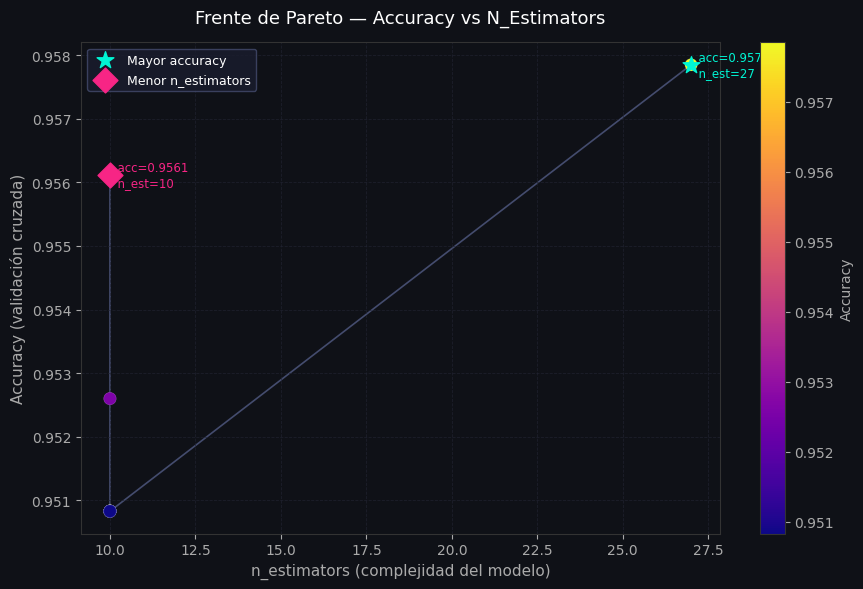

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Extraer los valores de ambos objetivos para cada solución del frente
accuracies   = [-s.objectives[0] for s in pareto_front]          # Volver a positivo
n_estimators = [max(10, int(round(s.variables[0]))) for s in pareto_front]

# Identificar los extremos para destacarlos en el gráfico
idx_mejor_acc  = int(np.argmax(accuracies))
idx_menor_nest = int(np.argmin(n_estimators))

fig, ax = plt.subplots(figsize=(9, 6))
fig.patch.set_facecolor("#0f1117")
ax.set_facecolor("#0f1117")

# --- Línea que conecta el frente (ordenado por n_estimators) ---
orden = np.argsort(n_estimators)
x_ord = [n_estimators[i] for i in orden]
y_ord = [accuracies[i]   for i in orden]
ax.plot(x_ord, y_ord, color="#444c6e", linewidth=1.2, zorder=1)

# --- Puntos del frente ---
scatter = ax.scatter(
    n_estimators,
    accuracies,
    c=accuracies,               # Color según accuracy
    cmap="plasma",
    s=80,
    zorder=2,
    edgecolors="#ffffff22",
    linewidths=0.5
)

# --- Destacar extremos ---
ax.scatter(
    n_estimators[idx_mejor_acc],
    accuracies[idx_mejor_acc],
    s=160, color="#00f5d4", zorder=3, label="Mayor accuracy", marker="*"
)
ax.scatter(
    n_estimators[idx_menor_nest],
    accuracies[idx_menor_nest],
    s=160, color="#f72585", zorder=3, label="Menor n_estimators", marker="D"
)

# --- Anotaciones de los extremos ---
ax.annotate(
    f"  acc={accuracies[idx_mejor_acc]:.4f}\n  n_est={n_estimators[idx_mejor_acc]}",
    xy=(n_estimators[idx_mejor_acc], accuracies[idx_mejor_acc]),
    color="#00f5d4", fontsize=8.5, va="center"
)
ax.annotate(
    f"  acc={accuracies[idx_menor_nest]:.4f}\n  n_est={n_estimators[idx_menor_nest]}",
    xy=(n_estimators[idx_menor_nest], accuracies[idx_menor_nest]),
    color="#f72585", fontsize=8.5, va="center"
)

# --- Colorbar ---
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Accuracy", color="#aaaaaa", fontsize=10)
cbar.ax.yaxis.set_tick_params(color="#aaaaaa")
plt.setp(cbar.ax.yaxis.get_ticklabels(), color="#aaaaaa")
cbar.outline.set_edgecolor("#333333")

# --- Estilos de ejes ---
ax.set_xlabel("n_estimators (complejidad del modelo)", color="#aaaaaa", fontsize=11)
ax.set_ylabel("Accuracy (validación cruzada)",         color="#aaaaaa", fontsize=11)
ax.set_title("Frente de Pareto — Accuracy vs N_Estimators", color="#ffffff", fontsize=13, pad=14)

ax.tick_params(colors="#aaaaaa")
for spine in ax.spines.values():
    spine.set_edgecolor("#333333")

ax.legend(facecolor="#1a1d2e", edgecolor="#444c6e", labelcolor="#ffffff", fontsize=9)
ax.grid(color="#222533", linestyle="--", linewidth=0.6, alpha=0.7)

plt.tight_layout()
plt.show()